# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from IPython.core.display_functions import clear_output

# Load data

In [3]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../../data/preprocessed-data"
morph_folder = "../../../data/morphological-data"

In [4]:
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv']


In [14]:
df_rois, df_fields, df_outline= data_loader.load_all_dfs(data_folder)

In [15]:
df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv',
    nuc_col_master='Final NucID',
    seg_col_master='Final SegID',
    df_rois=df_rois,
)

# Plot data

In [16]:
row = df.iloc[0]

In [17]:
row.seg_id  # You can view this in neuroglancer

'720575940557124706'

In [28]:
chirp_time = np.arange(row.chirp_trace.size) * row.chirp_trace_dt + row.chirp_trace_t0
bar_time = np.arange(row.bar_trace.size) * row.bar_trace_dt + row.bar_trace_t0
mc_time  = np.arange(row.mc_trace.size) * row.mc_trace_dt + row.mc_trace_t0

In [29]:
from eyewire2_functional_analysis.plot import plot_chirp, plot_bar

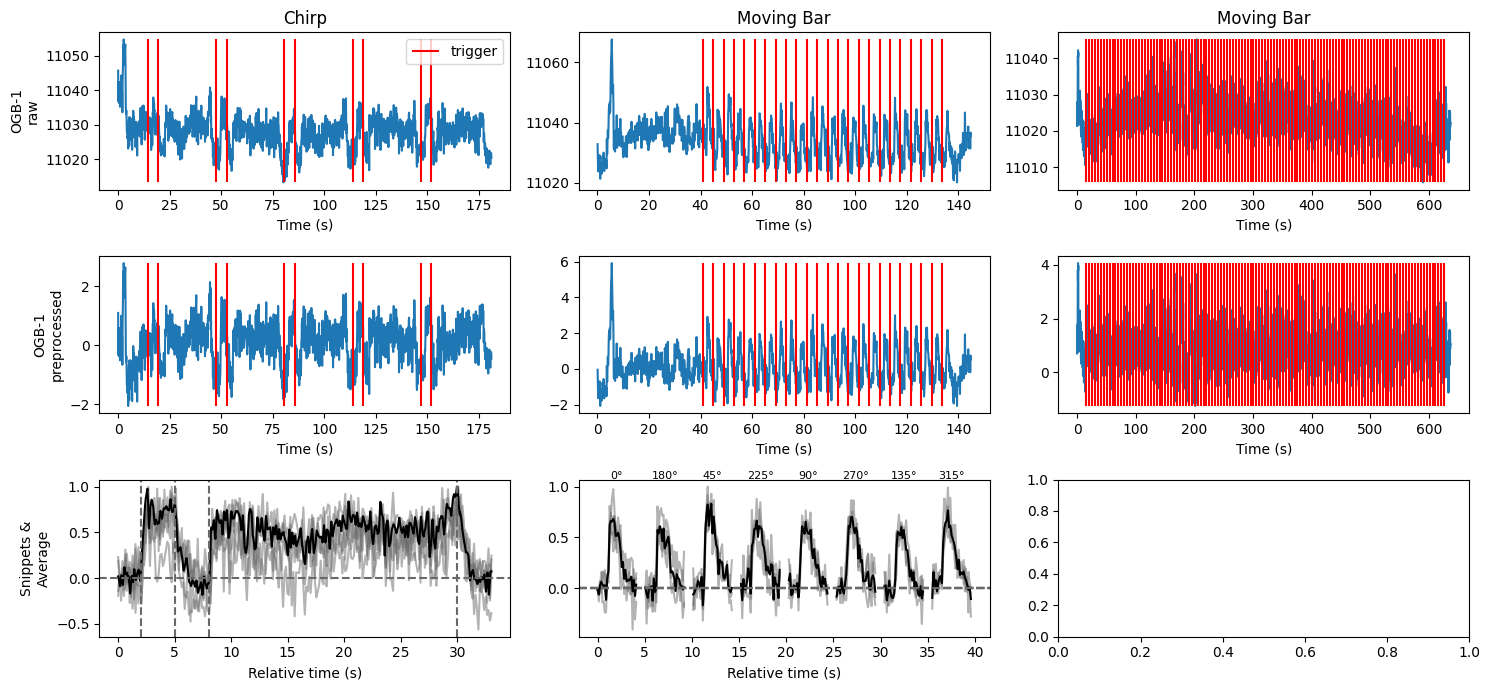

In [41]:
fig, axs = plt.subplots(3, 3, figsize=(15, 7))

# Raw
ax = axs[0, 0]
ax.plot(chirp_time, row.chirp_trace)
ax.vlines(row.chirp_triggertimes_snippets.flatten(), ymin=row.chirp_trace.min(), ymax=row.chirp_trace.max(), color='r', label='trigger')
ax.set(xlabel='Time (s)', ylabel='OGB-1\nraw', title='Chirp')
ax.legend(loc='upper right')

ax = axs[0, 1]
ax.plot(bar_time, row.bar_trace)
ax.vlines(row.bar_triggertimes_snippets.flatten(), ymin=row.bar_trace.min(), ymax=row.bar_trace.max(), color='r')
ax.set(xlabel='Time (s)', title='Moving Bar')

ax = axs[0, 2]
ax.plot(mc_time, row.mc_trace)
ax.vlines(row.mc_triggertimes.flatten(), ymin=row.mc_trace.min(), ymax=row.mc_trace.max(), color='r')
ax.set(xlabel='Time (s)', title='Moving Bar')

# Preprocessed
ax = axs[1, 0]
ax.plot(chirp_time, row.chirp_pp_trace)
ax.vlines(row.chirp_triggertimes_snippets.flatten(), ymin=row.chirp_pp_trace.min(), ymax=row.chirp_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)', ylabel='OGB-1\npreprocessed')

ax = axs[1, 1]
ax.plot(bar_time, row.bar_pp_trace)
ax.vlines(row.bar_triggertimes_snippets.flatten(), ymin=row.bar_pp_trace.min(), ymax=row.bar_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)')

ax = axs[1, 2]
ax.plot(mc_time, row.mc_pp_trace)
ax.vlines(row.mc_triggertimes.flatten(), ymin=row.mc_pp_trace.min(), ymax=row.mc_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)')

# Average and repeats
ax = axs[2, 0]
plot_chirp(ax=ax, row=row, stimulus_ms=None, plot_hline=True, plot_vlines=True)
ax.set(xlabel='Relative time (s)', ylabel='Snippets &\nAverage')

ax = axs[2, 1]
plot_bar(ax=ax, row=row, annotate_dirs=True, annotate_symbols=False, ventral_up=True)
ax.set(xlabel='Relative time (s)')

plt.tight_layout()